In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import fastf1

In [3]:
barcelona_session = fastf1.get_session(2026, 'Barcelona', 'Q')
barcelona_session.load(telemetry = True)

core           INFO 	Loading data for Barcelona Grand Prix - Qualifying [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['63', '44', '12', '1', '3', '6', '81', '30', '27', '16', '41', '5', '43', '10', '87', '55', '31', '23', '11', '77', '18', '14']


In [13]:
# Getting the laps of Qualifying
laps = barcelona_session.laps

In [23]:
# Getting the result of the Session then we will start analyzing. 

result = barcelona_session.results
result.head(10)

,DriverNumber,BroadcastName,Abbreviation,DriverId,TeamName,TeamColor,TeamId,FirstName,LastName,FullName,...,Position,ClassifiedPosition,GridPosition,Q1,Q2,Q3,Time,Status,Points,Laps
63,63,G RUSSELL,RUS,russell,Mercedes,00D7B6,mercedes,George,Russell,George Russell,...,1.0,,NaN,0 days 00:01:15.717000,0 days 00:01:15.228000,0 days 00:01:14.679000,NaT,,NaN,NaN
44,44,L HAMILTON,HAM,hamilton,Ferrari,ED1131,ferrari,Lewis,Hamilton,Lewis Hamilton,...,2.0,,NaN,0 days 00:01:15.625000,0 days 00:01:15.418000,0 days 00:01:14.743000,NaT,,NaN,NaN
12,12,K ANTONELLI,ANT,antonelli,Mercedes,00D7B6,mercedes,Kimi,Antonelli,Kimi Antonelli,...,3.0,,NaN,0 days 00:01:15.977000,0 days 00:01:15.295000,0 days 00:01:14.998000,NaT,,NaN,NaN
1,1,L NORRIS,NOR,norris,McLaren,F47600,mclaren,Lando,Norris,Lando Norris,...,4.0,,NaN,0 days 00:01:16.287000,0 days 00:01:15.361000,0 days 00:01:15.001000,NaT,,NaN,NaN
3,3,M VERSTAPPEN,VER,max_verstappen,Red Bull Racing,4781D7,red_bull,Max,Verstappen,Max Verstappen,...,5.0,,NaN,0 days 00:01:16.352000,0 days 00:01:15.484000,0 days 00:01:15.021000,NaT,,NaN,NaN
6,6,I HADJAR,HAD,hadjar,Red Bull Racing,4781D7,red_bull,Isack,Hadjar,Isack Hadjar,...,6.0,,NaN,0 days 00:01:16.427000,0 days 00:01:15.754000,0 days 00:01:15.077000,NaT,,NaN,NaN
81,81,O PIASTRI,PIA,piastri,McLaren,F47600,mclaren,Oscar,Piastri,Oscar Piastri,...,7.0,,NaN,0 days 00:01:16.138000,0 days 00:01:15.518000,0 days 00:01:15.090000,NaT,,NaN,NaN
30,30,L LAWSON,LAW,lawson,Racing Bulls,6C98FF,rb,Liam,Lawson,Liam Lawson,...,8.0,,NaN,0 days 00:01:16.673000,0 days 00:01:15.585000,0 days 00:01:16.542000,NaT,,NaN,NaN
27,27,N HULKENBERG,HUL,hulkenberg,Audi,F50537,audi,Nico,Hulkenberg,Nico Hulkenberg,...,9.0,,NaN,0 days 00:01:16.066000,0 days 00:01:15.768000,0 days 00:01:16.657000,NaT,,NaN,NaN
16,16,C LECLERC,LEC,leclerc,Ferrari,ED1131,ferrari,Charles,Leclerc,Charles Leclerc,...,10.0,,NaN,0 days 00:01:15.964000,0 days 00:01:15.281000,NaT,NaT,,NaN,NaN


In [30]:
# Hamilton and Russell has very close margin, so let's analyze their laps.
ham_laps = laps.pick_drivers('HAM')
rus_laps = laps.pick_drivers('RUS')

ham_fastest = ham_laps.pick_fastest()
rus_fastest = rus_laps.pick_fastest()

print(f"Hamilton's Fastest Lap of Qualifying: \n{ham_fastest}\n\nRussell's Fastest Lap of Qualifying: \n{rus_fastest}")

Hamilton's Fastest Lap of Qualifying: 
Time                      0 days 01:25:11.311000
Driver                                       HAM
DriverNumber                                  44
LapTime                   0 days 00:01:14.743000
LapNumber                                   13.0
Stint                                        5.0
PitOutTime                                   NaT
PitInTime                                    NaT
Sector1Time               0 days 00:00:21.886000
Sector2Time               0 days 00:00:30.008000
Sector3Time               0 days 00:00:22.849000
Sector1SessionTime        0 days 01:24:18.454000
Sector2SessionTime        0 days 01:24:48.462000
Sector3SessionTime        0 days 01:25:11.311000
SpeedI1                                    268.0
SpeedI2                                    288.0
SpeedFL                                    276.0
SpeedST                                    333.0
IsPersonalBest                              True
Compound                      

In [35]:
ham_fastest.info()

<class 'fastf1.core.Lap'>
Index: 31 entries, Time to IsAccurate
Series name: 25
Non-Null Count  Dtype 
--------------  ----- 
28 non-null     object
dtypes: object(1)
memory usage: 1.5+ KB


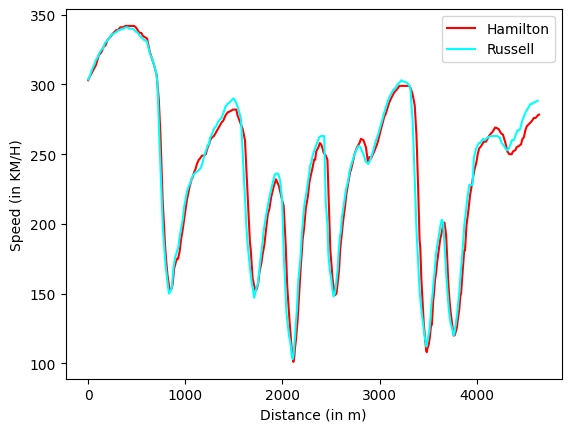

In [66]:
# Plotting boths laps
from fastf1 import plotting
plotting.setup_mpl()

telemetry_ham = ham_fastest.get_telemetry()
telemetry_rus = rus_fastest.get_telemetry()

plt.plot(telemetry_ham['Distance'], telemetry_ham['Speed'], color = 'red', label = 'Hamilton')
plt.plot(telemetry_rus['Distance'],telemetry_rus['Speed'],  color = 'cyan', label = 'Russell')
plt.xlabel("Distance (in m)")
plt.ylabel("Speed (in KM/H)")
plt.legend()
plt.show()

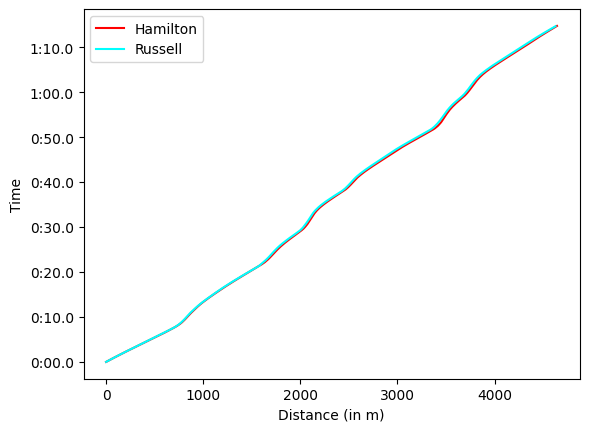

In [65]:
# Distance and Time Graph:

plt.plot(telemetry_ham['Distance'], telemetry_ham['Time'], color = 'red',  label = 'Hamilton')
plt.plot(telemetry_rus['Distance'],telemetry_rus['Time'], color = 'cyan' , label = 'Russell')
plt.xlabel("Distance (in m)")
plt.ylabel("Time")
plt.legend()
plt.show()

# Now analyzing the race...

In [45]:
race = fastf1.get_session(2026, 'Barcelona', 'R')
race.load(telemetry = True)

core           INFO 	Loading data for Barcelona Grand Prix - Race [v3.8.1]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No 

In [47]:
# Printing the race results

race_results = race.results
race_results.head(10)

,DriverNumber,BroadcastName,Abbreviation,DriverId,TeamName,TeamColor,TeamId,FirstName,LastName,FullName,...,Position,ClassifiedPosition,GridPosition,Q1,Q2,Q3,Time,Status,Points,Laps
44,44,L HAMILTON,HAM,hamilton,Ferrari,ED1131,ferrari,Lewis,Hamilton,Lewis Hamilton,...,1.0,1,2.0,NaT,NaT,NaT,0 days 01:32:28.105000,Finished,25.0,66.0
63,63,G RUSSELL,RUS,russell,Mercedes,00D7B6,mercedes,George,Russell,George Russell,...,2.0,2,1.0,NaT,NaT,NaT,0 days 00:00:19.561000,Finished,18.0,66.0
1,1,L NORRIS,NOR,norris,McLaren,F47600,mclaren,Lando,Norris,Lando Norris,...,3.0,3,4.0,NaT,NaT,NaT,0 days 00:00:23.719000,Finished,15.0,66.0
3,3,M VERSTAPPEN,VER,max_verstappen,Red Bull Racing,4781D7,red_bull,Max,Verstappen,Max Verstappen,...,4.0,4,5.0,NaT,NaT,NaT,0 days 00:00:40.497000,Finished,12.0,66.0
81,81,O PIASTRI,PIA,piastri,McLaren,F47600,mclaren,Oscar,Piastri,Oscar Piastri,...,5.0,5,7.0,NaT,NaT,NaT,0 days 00:00:58.661000,Finished,10.0,66.0
6,6,I HADJAR,HAD,hadjar,Red Bull Racing,4781D7,red_bull,Isack,Hadjar,Isack Hadjar,...,6.0,6,6.0,NaT,NaT,NaT,0 days 00:00:24.627000,Lapped,8.0,65.0
10,10,P GASLY,GAS,gasly,Alpine,00A1E8,alpine,Pierre,Gasly,Pierre Gasly,...,7.0,7,14.0,NaT,NaT,NaT,0 days 00:00:55.789000,Lapped,6.0,65.0
30,30,L LAWSON,LAW,lawson,Racing Bulls,6C98FF,rb,Liam,Lawson,Liam Lawson,...,8.0,8,8.0,NaT,NaT,NaT,0 days 00:01:12.224000,Lapped,4.0,65.0
41,41,A LINDBLAD,LIN,arvid_lindblad,Racing Bulls,6C98FF,rb,Arvid,Lindblad,Arvid Lindblad,...,9.0,9,11.0,NaT,NaT,NaT,0 days 00:01:18.074000,Lapped,2.0,65.0
43,43,F COLAPINTO,COL,colapinto,Alpine,00A1E8,alpine,Franco,Colapinto,Franco Colapinto,...,10.0,10,13.0,NaT,NaT,NaT,0 days 00:01:19.867000,Lapped,1.0,65.0


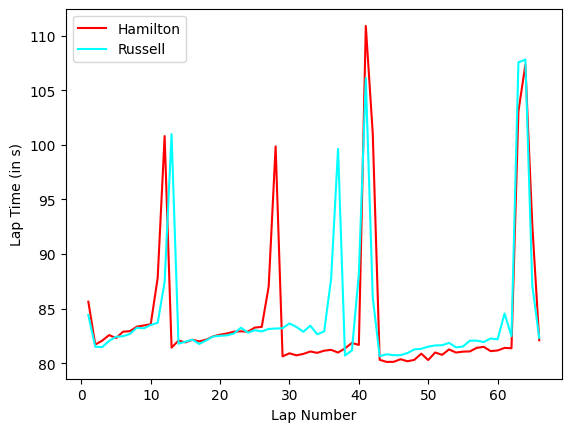

In [63]:
# Plotting the timings 

ham_laps = race.laps.pick_drivers('HAM')
rus_laps = race.laps.pick_drivers('RUS')


plt.plot(ham_laps['LapNumber'], ham_laps['LapTime'].dt.total_seconds(), label='Hamilton', color='red')
plt.plot(rus_laps['LapNumber'], rus_laps['LapTime'].dt.total_seconds(), label='Russell', color='cyan')

plt.xlabel("Lap Number")
plt.ylabel("Lap Time (in s)")
plt.legend()
plt.show()